# 🚀 HiPerGator Batch Job (SLURM) Setup

This section creates a ready-to-run SLURM job script for executing the full notebook on HiPerGator.

- The next cell writes `submit_job.sh` (as executable code).
- Then you can submit with `sbatch submit_job.sh`.
- A usage cell below includes all common monitoring/debug prompts.

In [1]:
print('test')

test


In [2]:
# RUN FIRST — Report utility initialization
from pathlib import Path
from datetime import datetime
import os
import sys
import subprocess

try:
    from docx import Document
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-docx"])
    from docx import Document

REPORT_PATH = Path("results/mdt_pipeline_report.docx")
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

if "REPORT_DOC" not in globals():
    REPORT_DOC = Document()
    REPORT_DOC.add_heading("Metacognitive Medical Digital Twins - Pipeline Report", 0)
    REPORT_DOC.add_paragraph(f"Generated: {datetime.now().isoformat()}")

def report_add_text(title: str, text: str):
    REPORT_DOC.add_heading(title, level=1)
    REPORT_DOC.add_paragraph(str(text))

def report_add_kv(title: str, kv: dict):
    REPORT_DOC.add_heading(title, level=1)
    for k, v in kv.items():
        REPORT_DOC.add_paragraph(f"{k}: {v}")

def report_add_dataframe(title: str, df, max_rows: int = 10):
    REPORT_DOC.add_heading(title, level=1)
    REPORT_DOC.add_paragraph(f"Rows: {len(df)} | Columns: {list(df.columns)}")
    REPORT_DOC.add_paragraph(df.head(max_rows).to_string(index=False))

def report_save(path: Path = REPORT_PATH):
    path.parent.mkdir(parents=True, exist_ok=True)
    REPORT_DOC.save(path)
    print(f"✓ DOCX report saved: {path.resolve()}")

print(f"✓ Report utility ready (run-first cell): {REPORT_PATH.resolve()}")

✓ Report utility ready (run-first cell): /blue/prismap-ai-core/Ahmed/DigitalTwins/MDT/results/mdt_pipeline_report.docx


## ✅ Run this first: DOCX report initialization
Before running any pipeline phase, execute the next code cell to initialize `REPORT_DOC` and `report_save` for cumulative reporting.

In [3]:
'''
from pathlib import Path
import os

job_script = """#!/bin/bash
#SBATCH --job-name=medical_digital_twin
#SBATCH --account=prismap-ai-core
#SBATCH --qos=prismap-ai-core
#SBATCH --partition=hpg-b200
#SBATCH --gres=gpu:b200:1  # Request B200 GPU (confirm availability)
#SBATCH --mem=64GB
#SBATCH --time=12:00:00
#SBATCH --output=job_output_%j.log
#SBATCH --error=job_error_%j.log

set -euo pipefail

# Ensure we are in submission directory
cd "${SLURM_SUBMIT_DIR:-$(pwd)}"

echo "[$(date)] Starting job ${SLURM_JOB_ID:-N/A} on $(hostname)"

# Load and activate conda environment (robust for non-interactive shells)
module purge
module load conda

if command -v conda >/dev/null 2>&1; then
    source "$(conda info --base)/etc/profile.d/conda.sh"
else
    echo "ERROR: conda command not found after module load." >&2
    exit 1
fi

conda activate digitaltwins_env

echo "Python: $(which python)"
echo "Jupyter: $(which jupyter || true)"

# Avoid ~/.local site-packages shadowing env packages on compute nodes
export PYTHONNOUSERSITE=1

if ! command -v jupyter >/dev/null 2>&1; then
    echo "ERROR: jupyter is not available in digitaltwins_env." >&2
    exit 1
fi

# Run the notebook (assuming jupyter is available in the environment)
jupyter nbconvert \\
    --to notebook \\
    --execute medical_digital_twin_master.ipynb \\
    --ExecutePreprocessor.timeout=-1 \\
    --output executed_notebook.ipynb

echo "[$(date)] Notebook execution completed. Output: executed_notebook.ipynb"

# Usage note: open in VS Code from login node after job finishes
echo "To open in VS Code from login node: code executed_notebook.ipynb"
"""

script_path = Path("submit_job.sh")
script_path.write_text(job_script)
os.chmod(script_path, 0o755)

print(f"✅ Wrote executable job script: {script_path.resolve()}")
'''

'\nfrom pathlib import Path\nimport os\n\njob_script = """#!/bin/bash\n#SBATCH --job-name=medical_digital_twin\n#SBATCH --account=prismap-ai-core\n#SBATCH --qos=prismap-ai-core\n#SBATCH --partition=hpg-b200\n#SBATCH --gres=gpu:b200:1  # Request B200 GPU (confirm availability)\n#SBATCH --mem=64GB\n#SBATCH --time=12:00:00\n#SBATCH --output=job_output_%j.log\n#SBATCH --error=job_error_%j.log\n\nset -euo pipefail\n\n# Ensure we are in submission directory\ncd "${SLURM_SUBMIT_DIR:-$(pwd)}"\n\necho "[$(date)] Starting job ${SLURM_JOB_ID:-N/A} on $(hostname)"\n\n# Load and activate conda environment (robust for non-interactive shells)\nmodule purge\nmodule load conda\n\nif command -v conda >/dev/null 2>&1; then\n    source "$(conda info --base)/etc/profile.d/conda.sh"\nelse\n    echo "ERROR: conda command not found after module load." >&2\n    exit 1\nfi\n\nconda activate digitaltwins_env\n\necho "Python: $(which python)"\necho "Jupyter: $(which jupyter || true)"\n\n# Avoid ~/.local site-pack

In [4]:
'''
usage_prompts = [
    "sbatch submit_job.sh",
    "squeue -u $USER",
    "sacct -j <JOB_ID> --format=JobID,JobName,Partition,State,Elapsed,MaxRSS",
    "tail -f job_output_<JOB_ID>.log",
    "tail -f job_error_<JOB_ID>.log",
    "ls -lh executed_notebook.ipynb",
    "code executed_notebook.ipynb"
]

print("📌 HiPerGator usage prompts:")
for i, cmd in enumerate(usage_prompts, start=1):
    print(f"{i}. {cmd}")

print("\nTip: replace <JOB_ID> with the value returned by sbatch.")
'''

'\nusage_prompts = [\n    "sbatch submit_job.sh",\n    "squeue -u $USER",\n    "sacct -j <JOB_ID> --format=JobID,JobName,Partition,State,Elapsed,MaxRSS",\n    "tail -f job_output_<JOB_ID>.log",\n    "tail -f job_error_<JOB_ID>.log",\n    "ls -lh executed_notebook.ipynb",\n    "code executed_notebook.ipynb"\n]\n\nprint("📌 HiPerGator usage prompts:")\nfor i, cmd in enumerate(usage_prompts, start=1):\n    print(f"{i}. {cmd}")\n\nprint("\nTip: replace <JOB_ID> with the value returned by sbatch.")\n'

In [5]:
#!sbatch submit_job.sh

In [6]:
#!squeue -u $USER

In [7]:
#!sacct -j 28307574 --format=JobID,JobName,Partition,State,Elapsed,MaxRSS

# Metacognitive Medical Digital Twins Pipeline

This notebook implements the complete MDT pipeline with MIMIC-IV and Medical-O1 data sources.

**Alignment Components:**
- Theory of Mind module for user belief inference
- Composite reward engine (5 components: safety, empathy, proactivity, metacognition, semantic)
- GRPO training for multi-objective alignment

**Ontology Components:**
- LOINC, SNOMED-CT, ICD-10 code mappings
- Clinical reference ranges validation
- MIMIC-IV item ID mappings

**Data Sources:**
- MIMIC-IV (ICU trajectories)
- Medical-O1 (reasoning chains)


## 1. Setup & Environment

In [8]:
pwd

'/blue/prismap-ai-core/Ahmed/DigitalTwins/MDT'

In [4]:
# Environment setup
import sys
sys.path.append(".")

# Core imports
from config.configs import DataConfig
from data.mimic_processor import MIMICProcessor
from data.medical_o1_processor import MedicalO1Processor
from data.think_alignment import apply_soft_think_alignment
from core.theory_of_mind import TheoryOfMindModule
from rewards.composite_engine import CompositeRewardEngine
from training.grpo_trainer import run_grpo_training
from utils.ontology_validator import OntologyValidator
from utils.helpers import clean_memory, setup_logging

print("✓ All components imported successfully")


Skipping import of cpp extensions due to incompatible torch version 2.9.1+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info
/blue/mrouhizadeh/ahmed.soliman/.conda/envs/digitaltwins_env/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


✓ All components imported successfully


In [5]:
# Report utility: save pipeline outputs to DOCX
from pathlib import Path
from datetime import datetime
import os
import sys
import subprocess

try:
    from docx import Document
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-docx"])
    from docx import Document

REPORT_PATH = Path("results/mdt_pipeline_report.docx")
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

if "REPORT_DOC" not in globals():
    REPORT_DOC = Document()
    REPORT_DOC.add_heading("Metacognitive Medical Digital Twins - Pipeline Report", 0)
    REPORT_DOC.add_paragraph(f"Generated: {datetime.now().isoformat()}")

def report_add_text(title: str, text: str):
    REPORT_DOC.add_heading(title, level=1)
    REPORT_DOC.add_paragraph(str(text))

def report_add_kv(title: str, kv: dict):
    REPORT_DOC.add_heading(title, level=1)
    for k, v in kv.items():
        REPORT_DOC.add_paragraph(f"{k}: {v}")

def report_add_dataframe(title: str, df, max_rows: int = 10):
    REPORT_DOC.add_heading(title, level=1)
    REPORT_DOC.add_paragraph(f"Rows: {len(df)} | Columns: {list(df.columns)}")
    REPORT_DOC.add_paragraph(df.head(max_rows).to_string(index=False))

def report_save(path: Path = REPORT_PATH):
    path.parent.mkdir(parents=True, exist_ok=True)
    REPORT_DOC.save(path)
    print(f"✓ DOCX report saved: {path.resolve()}")

print(f"✓ Reporting utility initialized: {REPORT_PATH.resolve()}")

✓ Reporting utility initialized: /blue/prismap-ai-core/Ahmed/DigitalTwins/MDT/results/mdt_pipeline_report.docx


## 2. Configuration

In [6]:
# Setup logging
setup_logging()
import logging
logger = logging.getLogger(__name__)

logger.info("="*80)
logger.info("MEDICAL DIGITAL TWIN - MASTER PIPELINE")
logger.info("="*80)

# Load configuration
data_config = DataConfig()
print(f"✓ Configuration loaded")
print(f"  MIMIC patients: {data_config.max_patients}")
print(f"  Medical-O1 examples: {data_config.max_o1_examples}")


2026-04-12 19:37:13,518 - __main__ - INFO - ================================================================================
2026-04-12 19:37:13,519 - __main__ - INFO - MEDICAL DIGITAL TWIN - MASTER PIPELINE
2026-04-12 19:37:13,519 - __main__ - INFO - ================================================================================
✓ Configuration loaded
  MIMIC patients: 1000
  Medical-O1 examples: 5000


## 3. Data Loading

In [7]:
# Load MIMIC-IV data
print("Loading MIMIC-IV data...")
mimic_processor = MIMICProcessor(data_config)

if mimic_processor.check_availability():
    mimic_data = mimic_processor.process_all_patients(
        max_patients=data_config.max_patients
    )
    print(f"✓ Loaded {len(mimic_data)} MIMIC examples")
    
    # Load ICD diagnoses for validation
    try:
        icd_diagnoses = mimic_processor.load_icd_diagnoses()
        print(f"✓ Loaded {len(icd_diagnoses)} ICD diagnoses")
    except Exception as e:
        print(f"⚠️ ICD diagnoses loading failed: {e}")
        icd_diagnoses = None
else:
    print("⚠️ MIMIC data not available")
    mimic_data = []
    icd_diagnoses = None

if "report_add_kv" in globals():
    report_add_kv("Data Phase - MIMIC Loading", {
        "MIMIC available": mimic_processor.check_availability(),
        "MIMIC examples loaded": len(mimic_data),
        "ICD diagnoses loaded": len(icd_diagnoses) if icd_diagnoses is not None else 0,
    })
    report_save()

Loading MIMIC-IV data...
2026-04-12 19:37:13,529 - data.mimic_processor - INFO - Initialized MIMIC-IV v3.1 processor
2026-04-12 19:37:13,529 - data.mimic_processor - INFO - Root directory: mimiciv/3.1
2026-04-12 19:37:13,529 - data.mimic_processor - INFO - Loaded 61 LOINC codes from ontology
2026-04-12 19:37:13,530 - data.mimic_processor - INFO - Loaded 19 chartevents item categories
2026-04-12 19:37:13,530 - data.mimic_processor - INFO - Loaded 32 reference ranges
2026-04-12 19:37:13,531 - data.mimic_processor - INFO - All required MIMIC-IV files found
2026-04-12 19:37:13,531 - data.mimic_processor - INFO - Processing up to 1000 patients...
2026-04-12 19:37:13,531 - data.mimic_processor - INFO - Loading ICU stays from: mimiciv/3.1/icu/icustays.csv
2026-04-12 19:37:13,620 - data.mimic_processor - INFO - Loaded 94458 ICU stays
2026-04-12 19:37:13,629 - data.mimic_processor - INFO - Selected 1000 ICU stays
2026-04-12 19:37:13,629 - data.mimic_processor - INFO - Extracting vital signs for

In [8]:
# Load Medical-O1 data
print("Loading Medical-O1 data...")
o1_processor = MedicalO1Processor()

try:
    o1_dataset = o1_processor.load_dataset(
        split='train',
        config=data_config.medical_o1_config
    )
    if o1_dataset:
        o1_data = o1_processor.format_for_training(
            o1_dataset,
            max_examples=data_config.max_o1_examples
        )
        o1_data = [{**item, 'source': 'medical_o1'} for item in o1_data]
        print(f"✓ Loaded {len(o1_data)} Medical-O1 examples")
    else:
        print("⚠️ Medical-O1 dataset loading failed")
        o1_data = []
except Exception as e:
    print(f"⚠️ Medical-O1 loading failed: {e}")
    o1_data = []

# Ensure source provenance on MIMIC
mimic_data = [{**item, 'source': item.get('source', 'mimic')} for item in mimic_data]

# Combine datasets
all_training_data = mimic_data + o1_data

# Soft mandatory CoT alignment: provenance + quality + weighting
all_training_data, alignment_summary = apply_soft_think_alignment(
    all_training_data,
    config=data_config
)
print("✓ Applied soft-mandatory CoT alignment")
print(f"  Gold think samples: {alignment_summary['gold_examples']}")
print(f"  Synthetic think samples: {alignment_summary['synthetic_examples']}")
print(f"  Synthetic quality pass rate: {alignment_summary['quality_pass_rate']:.2%}")
print(f"  Average think weight: {alignment_summary['avg_think_weight']:.3f}")

print(f"✓ Total training examples: {len(all_training_data)}")
print(f"  MIMIC-IV: {len(mimic_data)}")
print(f"  Medical-O1: {len(o1_data)}")

if "report_add_kv" in globals():
    report_add_kv("Data Phase - Combined Dataset", {
        "MIMIC-IV examples": len(mimic_data),
        "Medical-O1 examples": len(o1_data),
        "Total training examples": len(all_training_data),
        "Soft CoT gold samples": alignment_summary['gold_examples'],
        "Soft CoT synthetic samples": alignment_summary['synthetic_examples'],
        "Synthetic quality pass rate": alignment_summary['quality_pass_rate'],
        "Average think weight": alignment_summary['avg_think_weight'],
    })
    report_save()

Loading Medical-O1 data...
2026-04-12 19:37:15,858 - data.medical_o1_processor - INFO - Initialized MedicalO1Processor
2026-04-12 19:37:15,859 - data.medical_o1_processor - INFO - Loading FreedomIntelligence/medical-o1-reasoning-SFT (config=en) from HuggingFace...
2026-04-12 19:37:15,938 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/datasets/FreedomIntelligence/medical-o1-reasoning-SFT/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-04-12 19:37:15,958 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/FreedomIntelligence/medical-o1-reasoning-SFT/fc2c9e8a37b38f38da6d449564a8c350b244aef4/README.md "HTTP/1.1 200 OK"
2026-04-12 19:37:15,971 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/resolve-cache/datasets/FreedomIntelligence/medical-o1-reasoning-SFT/fc2c9e8a37b38f38da6d449564a8c350b244aef4/README.md "HTTP/1.1 200 OK"


README.md: 0.00B [00:00, ?B/s]

2026-04-12 19:37:16,027 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/datasets/FreedomIntelligence/medical-o1-reasoning-SFT/resolve/fc2c9e8a37b38f38da6d449564a8c350b244aef4/medical-o1-reasoning-SFT.py "HTTP/1.1 404 Not Found"
2026-04-12 19:37:16,128 - httpx - INFO - HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/FreedomIntelligence/medical-o1-reasoning-SFT/FreedomIntelligence/medical-o1-reasoning-SFT.py "HTTP/1.1 404 Not Found"
2026-04-12 19:37:16,174 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/datasets/FreedomIntelligence/medical-o1-reasoning-SFT/revision/fc2c9e8a37b38f38da6d449564a8c350b244aef4 "HTTP/1.1 200 OK"
2026-04-12 19:37:16,222 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/datasets/FreedomIntelligence/medical-o1-reasoning-SFT/resolve/fc2c9e8a37b38f38da6d449564a8c350b244aef4/.huggingface.yaml "HTTP/1.1 404 Not Found"


2026-04-12 19:37:16,223 - huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-04-12 19:37:16,308 - httpx - INFO - HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=FreedomIntelligence/medical-o1-reasoning-SFT "HTTP/1.1 200 OK"
2026-04-12 19:37:16,365 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/datasets/FreedomIntelligence/medical-o1-reasoning-SFT/tree/fc2c9e8a37b38f38da6d449564a8c350b244aef4?recursive=false&expand=false "HTTP/1.1 200 OK"
2026-04-12 19:37:16,456 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/datasets/FreedomIntelligence/medical-o1-reasoning-SFT/resolve/fc2c9e8a37b38f38da6d449564a8c350b244aef4/dataset_infos.json "HTTP/1.1 404 Not Found"
2026-04-12 19:37:16,511 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/datasets/FreedomIntelligence/medical-o1-reasoning-SFT/resolve/fc2c9e8a37b38f

medical_o1_sft.json:   0%|          | 0.00/58.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/19704 [00:00<?, ? examples/s]

2026-04-12 19:37:18,087 - data.medical_o1_processor - INFO - ✓ Loaded 19704 examples from Medical-O1 dataset
2026-04-12 19:37:18,087 - data.medical_o1_processor - INFO - Formatting 5000 Medical-O1 examples...
2026-04-12 19:37:18,273 - data.medical_o1_processor - INFO - ✓ Formatted 5000 Medical-O1 examples
✓ Loaded 5000 Medical-O1 examples
✓ Applied soft-mandatory CoT alignment
  Gold think samples: 5000
  Synthetic think samples: 160
  Synthetic quality pass rate: 100.00%
  Average think weight: 0.983
✓ Total training examples: 5160
  MIMIC-IV: 160
  Medical-O1: 5000
✓ DOCX report saved: /blue/prismap-ai-core/Ahmed/DigitalTwins/MDT/results/mdt_pipeline_report.docx


### 3.1 Soft-Mandatory CoT Alignment (Provenance + Weighting)

> This notebook now applies `apply_soft_think_alignment(...)` after combining MIMIC and Medical-O1 data.

Per-example fields added before SFT:
- `think_synth`, `think_source`, `think_confidence`, `think_quality_score`, `think_weight`
- Canonical reasoning (`think`/`reasoning`) remains available for prompt construction.

Weighting defaults:
- Gold CoT: `1.0`
- Synthetic high-quality: `0.45`
- Synthetic low-quality: `0.20`

## 3.2 Dataset Analysis & Visualizations
This section explores key dataset characteristics before training and stores summaries in the DOCX report.

--- Dataset Summary ---
MIMIC rows: 160
Medical-O1 rows: 5000
Combined rows: 5160

Top missing columns (%):
stay_id          96.899225
prompt            0.000000
think             0.000000
patient_state     0.000000
user_belief       0.000000
source            0.000000
reasoning         0.000000
think_gold        0.000000
think_synth       0.000000
think_source      0.000000


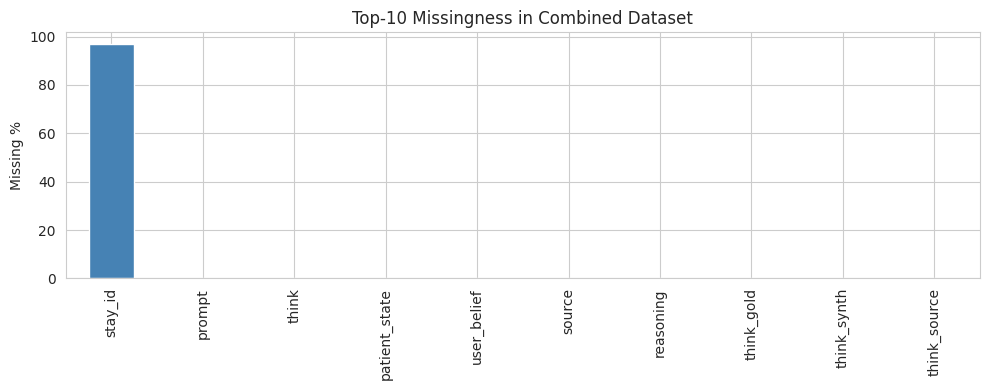

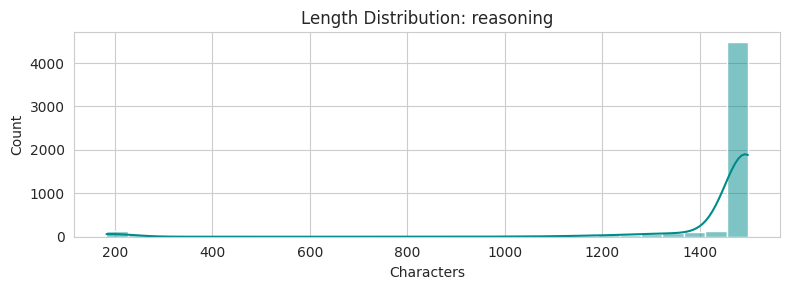

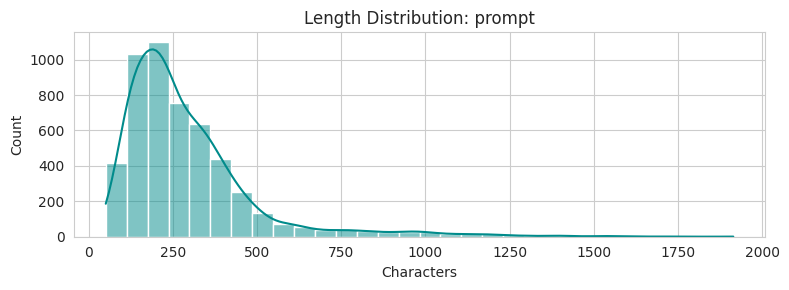


Text length stats:
           mean_len  median_len  max_len
reasoning   1437.29      1495.0   1499.0
prompt       292.79       240.0   1914.0
✓ DOCX report saved: /blue/prismap-ai-core/Ahmed/DigitalTwins/MDT/results/mdt_pipeline_report.docx


In [9]:
# Dataset analysis and visualizations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

mimic_df = pd.DataFrame(mimic_data) if isinstance(mimic_data, list) else pd.DataFrame()
o1_df = pd.DataFrame(o1_data) if isinstance(o1_data, list) else pd.DataFrame()
all_df = pd.DataFrame(all_training_data) if isinstance(all_training_data, list) else pd.DataFrame()

print("--- Dataset Summary ---")
print(f"MIMIC rows: {len(mimic_df)}")
print(f"Medical-O1 rows: {len(o1_df)}")
print(f"Combined rows: {len(all_df)}")

if len(all_df) > 0:
    # Missingness overview
    missing_pct = all_df.isna().mean().sort_values(ascending=False).head(10) * 100
    print("\nTop missing columns (%):")
    print(missing_pct.to_string())

    plt.figure(figsize=(10, 4))
    missing_pct.plot(kind="bar", color="steelblue")
    plt.title("Top-10 Missingness in Combined Dataset")
    plt.ylabel("Missing %")
    plt.tight_layout()
    plt.show()

    # Text-length analysis if key fields exist
    candidate_cols = [c for c in ["case_description", "reasoning", "response", "prompt"] if c in all_df.columns]
    if candidate_cols:
        length_stats = {}
        for col in candidate_cols:
            lens = all_df[col].fillna("").astype(str).map(len)
            length_stats[col] = {
                "mean_len": round(float(lens.mean()), 2),
                "median_len": round(float(lens.median()), 2),
                "max_len": int(lens.max()),
            }
            
            plt.figure(figsize=(8, 3))
            sns.histplot(lens, bins=30, kde=True, color="darkcyan")
            plt.title(f"Length Distribution: {col}")
            plt.xlabel("Characters")
            plt.tight_layout()
            plt.show()

        print("\nText length stats:")
        print(pd.DataFrame(length_stats).T)

        if "report_add_kv" in globals():
            report_add_kv("Dataset Summary", {
                "MIMIC rows": len(mimic_df),
                "Medical-O1 rows": len(o1_df),
                "Combined rows": len(all_df),
                "Columns": list(all_df.columns),
            })
            report_add_text("Missingness (Top 10)", missing_pct.to_string())
            report_add_text("Text Length Stats", pd.DataFrame(length_stats).T.to_string())
            report_save()
    else:
        print("No expected text columns found for length visualization.")

else:
    print("Combined dataset is empty; skipping EDA plots.")

## 3.5. Ontology Validation

In [10]:
# Initialize ontology validator
print("Initializing ontology validator...")
ontology_validator = OntologyValidator()

# Validate ICD codes if available
if icd_diagnoses is not None:
    print("Validating ICD-10 codes...")
    valid_icd_count = 0
    total_icd_count = len(icd_diagnoses)
    
    # Sample validation (check first 100 for speed)
    sample_icd = icd_diagnoses.head(100)
    for _, row in sample_icd.iterrows():
        icd_code = row['icd_code']
        if ontology_validator.validate_icd10_code(icd_code):
            valid_icd_count += 1
    
    print(f"✓ ICD-10 validation: {valid_icd_count}/{len(sample_icd)} sample codes valid")
    print(f"  Total ICD diagnoses available: {total_icd_count}")
else:
    print("⚠️ ICD diagnoses not available for validation")
    valid_icd_count = 0
    total_icd_count = 0
    sample_icd = []

# Validate LOINC codes from loaded data
print("Validating LOINC codes...")
loinc_codes = ontology_validator.loinc_codes
print(f"✓ Loaded {len(loinc_codes)} LOINC codes in ontology")

# Test some common LOINC codes
test_loinc = ['8867-4', '8480-6', '8462-4', '2524-7', '2160-0']  # HR, SBP, DBP, Lactate, Creatinine
valid_loinc_count = 0
for code in test_loinc:
    if ontology_validator.validate_loinc_code(code):
        valid_loinc_count += 1

print(f"✓ LOINC validation: {valid_loinc_count}/{len(test_loinc)} test codes valid")

# Validate SNOMED-CT codes
print("Validating SNOMED-CT codes...")
snomed_codes = ontology_validator.snomed_codes
print(f"✓ Loaded {len(snomed_codes)} SNOMED-CT codes in ontology")

# Test some common SNOMED codes
test_snomed = ['91302008', '233604007', '67782005', '84114007', '22298006']  # Sepsis, Pneumonia, ARDS, Heart Failure, MI
valid_snomed_count = 0
for code in test_snomed:
    if ontology_validator.validate_snomed_code(code):
        valid_snomed_count += 1

print(f"✓ SNOMED-CT validation: {valid_snomed_count}/{len(test_snomed)} test codes valid")

print("✓ Complete ontology validation completed")

if "report_add_kv" in globals():
    report_add_kv("Validation Phase - Ontology", {
        "ICD sample valid": f"{valid_icd_count}/{len(sample_icd) if hasattr(sample_icd, '__len__') else 0}",
        "LOINC test valid": f"{valid_loinc_count}/{len(test_loinc)}",
        "SNOMED test valid": f"{valid_snomed_count}/{len(test_snomed)}",
        "LOINC ontology size": len(loinc_codes),
        "SNOMED ontology size": len(snomed_codes),
    })
    report_save()

Initializing ontology validator...
2026-04-12 19:37:18,834 - utils.ontology_validator - INFO - Initialized OntologyValidator
2026-04-12 19:37:18,837 - utils.ontology_validator - INFO -   LOINC codes: 61
2026-04-12 19:37:18,837 - utils.ontology_validator - INFO -   SNOMED codes: 50
2026-04-12 19:37:18,838 - utils.ontology_validator - INFO -   ICD-10 codes: 52
2026-04-12 19:37:18,839 - utils.ontology_validator - INFO -   Reference ranges: 32
Validating ICD-10 codes...
✓ ICD-10 validation: 2/100 sample codes valid
  Total ICD diagnoses available: 6364488
Validating LOINC codes...
✓ Loaded 61 LOINC codes in ontology
✓ LOINC validation: 5/5 test codes valid
Validating SNOMED-CT codes...
✓ Loaded 50 SNOMED-CT codes in ontology
✓ SNOMED-CT validation: 5/5 test codes valid
✓ Complete ontology validation completed
✓ DOCX report saved: /blue/prismap-ai-core/Ahmed/DigitalTwins/MDT/results/mdt_pipeline_report.docx


## 4. Model Training (SFT)

In [16]:
# Import SFT training components
from training.sft_trainer import run_sft_training
from models.mdt_model import MedicalDigitalTwinModel
from config.configs import ModelConfig, SFTConfig
from data.dataset import CognitiveStreamDataset
import os
import json

# Initialize model configuration
model_config = ModelConfig()
print(f"✓ Model config loaded: {model_config.model_name}")

# Initialize SFT training configuration
sft_config = SFTConfig()
print(f"✓ SFT config loaded: {sft_config.num_epochs} epochs")

# Initialize model
model = MedicalDigitalTwinModel(model_config)

# Prepare training data split
if len(all_training_data) > 0:
    # Split data for training and evaluation (90% train, 10% eval)
    split_idx = int(len(all_training_data) * 0.9)
    train_data = all_training_data[:split_idx]
    eval_data = all_training_data[split_idx:]
    
    # Create dataset objects
    train_dataset = CognitiveStreamDataset(
        train_data,
        model.tokenizer,
        max_length=model_config.max_length
    )
    
    eval_dataset = CognitiveStreamDataset(
        eval_data,
        model.tokenizer,
        max_length=model_config.max_length
    )
    
    print(f"✓ Data split: {len(train_dataset)} train, {len(eval_dataset)} eval examples")
else:
    train_dataset = None
    eval_dataset = None
    print("⚠️ No training data available")

# Run SFT training
print("Starting SFT training...")
if train_dataset is not None and eval_dataset is not None:
    trained_model = run_sft_training(
        model=model,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        config=sft_config
    )
    print("✓ SFT training completed")

    # Post-run diagnostics for under-training / no-step runs
    history_path = "outputs/sft/training_history.json"
    total_steps = 0
    losses = []
    if os.path.exists(history_path):
        try:
            with open(history_path, "r") as f:
                history = json.load(f)

            total_steps = int(history.get("total_steps", 0) or 0)
            losses = history.get("training_losses", [])

            if total_steps == 0:
                print("⚠️ Diagnostic: total_steps=0. Optimizer updates did not occur.")
                print("   Likely cause: too few batches vs gradient_accumulation_steps.")
                print("   Consider reducing SFTConfig.gradient_accumulation_steps or increasing training data.")

            if len(losses) <= 1:
                print(f"⚠️ Diagnostic: only {len(losses)} training loss point(s) logged.")
                print("   The loss curve is not yet meaningful; run with more steps/data.")
        except Exception as e:
            print(f"⚠️ Could not parse SFT history diagnostics: {e}")
    else:
        print("⚠️ SFT history file not found; unable to run post-training diagnostics.")

    if "report_add_kv" in globals():
        report_add_kv("Training Phase - SFT", {
            "Model": model_config.model_name,
            "Train examples": len(train_dataset),
            "Eval examples": len(eval_dataset),
            "Configured epochs": sft_config.num_epochs,
            "Fallback total steps": total_steps,
            "Fallback loss points": len(losses),
        })
        report_save()
else:
    print("⚠️ Skipping SFT training - no data available")
    trained_model = model

✓ Model config loaded: Qwen/Qwen3.5-4B
✓ SFT config loaded: 3 epochs
2026-04-10 20:44:43,794 - models.mdt_model - WARNING - Using GPT-2 for demo. Set use_demo_model=False for production.
2026-04-10 20:44:43,803 - models.mdt_model - INFO - Loading GPT-2 demo model...
2026-04-10 20:44:43,855 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/config.json "HTTP/1.1 200 OK"
2026-04-10 20:44:43,904 - httpx - INFO - HTTP Request: GET https://huggingface.co/gpt2/resolve/main/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

2026-04-10 20:44:43,975 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
2026-04-10 20:44:44,134 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/config.json "HTTP/1.1 200 OK"
2026-04-10 20:44:44,181 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-04-10 20:44:44,224 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/openai-community/gpt2/xet-read-token/607a30d783dfa663caf39e06633721c8d4cfcd7e "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Step,Training Loss,Validation Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-10 21:02:22,143 - training.sft_trainer - INFO - 
2026-04-10 21:02:22,143 - training.sft_trainer - INFO - Saving final model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-10 21:02:22,541 - training.sft_trainer - INFO - 
2026-04-10 21:02:22,541 - training.sft_trainer - INFO - ================================================================================
2026-04-10 21:02:22,542 - training.sft_trainer - INFO - SUPERVISED FINE-TUNING COMPLETE
2026-04-10 21:02:22,542 - training.sft_trainer - INFO - ================================================================================
2026-04-10 21:02:22,542 - training.sft_trainer - INFO -   Final loss: 21.9350
2026-04-10 21:02:22,542 - training.sft_trainer - INFO -   Total steps: 438
2026-04-10 21:02:22,542 - training.sft_trainer - INFO -   Model saved to: outputs/sft/final_model
2026-04-10 21:02:22,543 - training.sft_trainer - INFO -   Logs saved to: outputs/logs/sft
2026-04-10 21:02:22,543 - training.sft_trainer - INFO - ================================================================================
2026-04-10 21:02:22,543 - training.sft_trainer - INFO - 
✓ SFT training completed
⚠️ Diagnostic: total_

In [17]:
# View SFT Training Results
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

print("--- SFT Training Results ---")

def _fmt_float(value, digits=4):
    try:
        return f"{float(value):.{digits}f}"
    except (TypeError, ValueError):
        return "N/A"

metrics_path = "outputs/sft/training_metrics.json"
has_trainer_metrics = os.path.exists(metrics_path)

if has_trainer_metrics:
    with open(metrics_path, "r") as f:
        metrics = json.load(f)
    
    print(f"Final Training Loss: {_fmt_float(metrics.get('train_loss'))}")
    print(f"Total Steps: {metrics.get('total_steps', 'N/A')}")
    print(f"Total Epochs: {metrics.get('epoch', 'N/A')}")
    print(f"Runtime: {_fmt_float(metrics.get('train_runtime'), 2)} seconds")
    print(f"Samples per second: {metrics.get('train_samples_per_second', 'N/A')}")
    print("✓ Using Hugging Face Trainer metrics (authoritative for this run).")

    if "report_add_kv" in globals():
        report_add_kv("Training Metrics - SFT", {
            "Final training loss": _fmt_float(metrics.get('train_loss')),
            "Total steps": metrics.get('total_steps', 'N/A'),
            "Total epochs": metrics.get('epoch', 'N/A'),
            "Runtime (s)": _fmt_float(metrics.get('train_runtime'), 2),
            "Samples/sec": metrics.get('train_samples_per_second', 'N/A'),
        })
        report_save()
else:
    print("Could not find Hugging Face Trainer metrics. Checking for basic loop history...")

    history_path = "outputs/sft/training_history.json"
    if os.path.exists(history_path):
        with open(history_path, "r") as f:
            history = json.load(f)

        losses = history.get('training_losses', [])
        if losses:
            epochs = list(range(1, len(losses) + 1))

            plt.figure(figsize=(8, 4))
            plt.plot(epochs, losses, marker='o', label='Training Loss')
            plt.title('SFT Training Curve')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.xticks(epochs)
            plt.grid(True)
            plt.legend()

            if len(losses) == 1:
                plt.xlim(0.5, 1.5)
                print("⚠️ Only one loss point found (single epoch/summary). Curve shape is not meaningful yet.")

            plt.show()

            print(f"History points: {len(losses)}")
            print(f"First loss: {losses[0]:.4f} | Last loss: {losses[-1]:.4f}")

            if "report_add_text" in globals():
                report_add_text("Training Metrics - SFT (Fallback History)", f"History points: {len(losses)}\nFirst loss: {losses[0]:.4f}\nLast loss: {losses[-1]:.4f}")
                report_save()
        else:
            print("⚠️ training_history.json exists but contains no 'training_losses'.")
    else:
        print("⚠️ No SFT history file found at outputs/sft/training_history.json")

# If tensorboard logs exist, we can enable it inline
print("\nTo view detailed interactive loss curves, you can run this command in a new cell:")
print("%load_ext tensorboard")
print("%tensorboard --logdir outputs/sft/runs/")

--- SFT Training Results ---
Final Training Loss: 21.9350
Total Steps: 438
Total Epochs: 3.0
Runtime: 1054.16 seconds
Samples per second: 13.216
✓ Using Hugging Face Trainer metrics (authoritative for this run).
✓ DOCX report saved: /blue/prismap-ai-core/Ahmed/DigitalTwins/MDT/results/mdt_pipeline_report.docx

To view detailed interactive loss curves, you can run this command in a new cell:
%load_ext tensorboard
%tensorboard --logdir outputs/sft/runs/


In [18]:
#%load_ext tensorboard
#%tensorboard --logdir outputs/sft/runs/

## 5. Alignment Training (GRPO)

In [19]:
# Import GRPO training components
from pathlib import Path
import json
from training.grpo_trainer import run_grpo_training
from config.configs import GRPOConfig
from data.dataset import CognitiveStreamDataset
from torch.utils.data import DataLoader

# Initialize reward engine
reward_engine = CompositeRewardEngine()

# Create GRPO configuration
grpo_config = GRPOConfig()
print(f"✓ GRPO config loaded: {grpo_config.num_iterations} default iterations")

# --- Resume-aware GRPO setup ---
grpo_output_dir = Path(grpo_config.output_dir)
grpo_output_dir.mkdir(parents=True, exist_ok=True)
resume_chunk = 200  # Increase target by this many iterations when resuming

def latest_completed_iteration(grpo_path: Path) -> int:
    latest = 0
    if not grpo_path.exists():
        return latest

    # From iteration_* checkpoint folders
    for child in grpo_path.iterdir():
        if child.is_dir() and child.name.startswith("iteration_"):
            try:
                latest = max(latest, int(child.name.replace("iteration_", "", 1)))
            except ValueError:
                pass

    # From training_stats.json (if present)
    stats_path = grpo_path / "training_stats.json"
    if stats_path.exists():
        try:
            with open(stats_path, "r") as f:
                stats = json.load(f)
            if isinstance(stats, dict) and stats.get("iterations"):
                latest = max(latest, int(stats["iterations"][-1]))
        except Exception as e:
            print(f"⚠️ Could not parse training_stats.json for resume info: {e}")

    return latest

latest_iter = latest_completed_iteration(grpo_output_dir)
if latest_iter > 0:
    # Ensure new run continues beyond latest checkpoint
    grpo_config.num_iterations = max(grpo_config.num_iterations, latest_iter + resume_chunk)
    print(f"✓ Resume checkpoint detected at iteration {latest_iter}")
    print(f"✓ New GRPO target iteration set to {grpo_config.num_iterations}")
else:
    print("✓ No previous GRPO checkpoint found; starting fresh GRPO run")
    print(f"✓ GRPO target iteration: {grpo_config.num_iterations}")

# Create dataloader for GRPO training
if train_dataset is not None:
    # Use batch_size=1 for GRPO since it processes prompts individually
    grpo_dataloader = DataLoader(
        train_dataset,
        batch_size=1,  # Process one prompt at a time for GRPO
        shuffle=True
    )
    print(f"✓ Created GRPO dataloader with {len(train_dataset)} examples")
else:
    grpo_dataloader = None
    print("⚠️ No training data available for GRPO")

if "report_add_kv" in globals():
    report_add_kv("Training Phase - GRPO Setup", {
        "Initial latest iteration": latest_iter,
        "Target iterations": grpo_config.num_iterations,
        "Batch size": grpo_config.batch_size,
        "Generations/prompt": grpo_config.num_generations_per_prompt,
        "Learning rate": grpo_config.learning_rate,
    })
    report_save()

# Run GRPO alignment (trainer auto-resumes from latest checkpoint/stats)
print("Starting GRPO alignment training...")
if grpo_dataloader is not None:
    aligned_model = run_grpo_training(
        model=trained_model,
        train_dataloader=grpo_dataloader,
        config=grpo_config,
        reward_engine=reward_engine
    )
    print("✓ GRPO alignment completed")
    
    # Record post-training GRPO status
    latest_after = latest_completed_iteration(grpo_output_dir)
    if "report_add_kv" in globals():
        report_add_kv("Training Phase - GRPO Completion", {
            "Latest completed iteration": latest_after,
            "Configured target iterations": grpo_config.num_iterations,
            "Output directory": str(grpo_output_dir),
        })
        report_save()
else:
    print("⚠️ Skipping GRPO training - no dataloader available")
    aligned_model = trained_model

2026-04-10 21:02:22,611 - absl - INFO - Using default tokenizer.
2026-04-10 21:02:22,762 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/roberta-large/resolve/main/config.json "HTTP/1.1 200 OK"
2026-04-10 21:02:22,808 - httpx - INFO - HTTP Request: GET https://huggingface.co/roberta-large/resolve/main/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

2026-04-10 21:02:22,855 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/roberta-large/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-04-10 21:02:22,904 - httpx - INFO - HTTP Request: GET https://huggingface.co/roberta-large/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

2026-04-10 21:02:22,953 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/roberta-large/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-04-10 21:02:23,001 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/FacebookAI/roberta-large/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-04-10 21:02:23,044 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/roberta-large/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-04-10 21:02:23,090 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/FacebookAI/roberta-large/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-04-10 21:02:23,134 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/roberta-large/resolve/main/vocab.json "HTTP/1.1 200 OK"
2026-04-10 21:02:23,181 - httpx - INFO - HTTP Request: GET https://huggingface.co/roberta-larg

...

2026-04-11 00:05:57,644 - models.mdt_model - WARNING - Input/output embedding mismatch detected (input_rows=50263, output_rows=50257). Attempting tie_weights().
2026-04-11 00:06:00,875 - models.mdt_model - WARNING - Input/output embedding mismatch detected (input_rows=50263, output_rows=50257). Attempting tie_weights().
2026-04-11 00:06:01,791 - models.mdt_model - WARNING - Input/output embedding mismatch detected (input_rows=50263, output_rows=50257). Attempting tie_weights().
2026-04-11 00:06:05,025 - models.mdt_model - WARNING - Input/output embedding mismatch detected (input_rows=50263, output_rows=50257). Attempting tie_weights().
2026-04-11 00:06:06,243 - models.mdt_model - WARNING - Input/output embedding mismatch detected (input_rows=50263, output_rows=50257). Attempting tie_weights().
2026-04-11 00:06:06,920 - models.mdt_model - WARNING - Input/output embedding mismatch detected (input_rows=50263, output_rows=50257). Attempting tie_weights().
2026-04-11 00:06:07,645 - models.m

2026-04-11 00:06:51,683 - training.grpo_trainer - INFO -   Updating policy...


2026-04-11 00:06:54,001 - training.grpo_trainer - INFO -   Avg Reward: 0.5318 (min: 0.5025, max: 0.5518)
2026-04-11 00:06:54,002 - training.grpo_trainer - INFO -   Policy Loss: 0.36343405 (3.634e-01)
2026-04-11 00:06:54,002 - training.grpo_trainer - INFO -   KL Divergence: 0.00000000 (0.000e+00)
2026-04-11 00:06:54,002 - training.grpo_trainer - INFO -   Reward Components: sem=0.7902, meta=0.2962, emp=0.0000, pro=0.5000, safe=1.0000
2026-04-11 00:06:54,002 - training.grpo_trainer - INFO - 
2026-04-11 00:06:54,354 - training.grpo_trainer - INFO -   Running evaluation...
2026-04-11 00:06:54,355 - training.grpo_trainer - INFO - 
2026-04-11 00:06:54,355 - training.grpo_trainer - INFO - Saving final policy...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-11 00:06:55,120 - training.grpo_trainer - INFO - 
2026-04-11 00:06:55,121 - training.grpo_trainer - INFO - ================================================================================
2026-04-11 00:06:55,121 - training.grpo_trainer - INFO - GRPO TRAINING COMPLETE
2026-04-11 00:06:55,121 - training.grpo_trainer - INFO - ================================================================================
2026-04-11 00:06:55,121 - training.grpo_trainer - INFO -   Final average reward: 0.5318
2026-04-11 00:06:55,121 - training.grpo_trainer - INFO -   Total iterations: 1250
2026-04-11 00:06:55,122 - training.grpo_trainer - INFO -   Model saved to: outputs/grpo/final_policy
2026-04-11 00:06:55,122 - training.grpo_trainer - INFO - ================================================================================
2026-04-11 00:06:55,122 - training.grpo_trainer - INFO - 
✓ GRPO alignment completed
✓ DOCX report saved: /blue/prismap-ai-core/Ahmed/DigitalTwins/MDT/results/mdt_pipeline_repor

In [24]:
# Import evaluation and helpers
from evaluation.evaluator import MedicalTwinEvaluator
from core.cognitive_streams import CognitiveStreamParser
import os
import sys

# Check if reward_engine is initialized earlier in the notebook, if not create one
if 'reward_engine' not in locals():
    print("Warning: reward_engine not found, initializing a new one for evaluation.")
    from rewards.composite_engine import CompositeRewardEngine
    reward_engine = CompositeRewardEngine()

# Initialize parser
from config.configs import CognitiveArchitectureConfig
cog_config = CognitiveArchitectureConfig()
parser = CognitiveStreamParser(cog_config)

# Ensure we have an aligned_model in the kernel. If missing, attempt to locate and load a checkpoint.
def _attempt_load_checkpoint(paths):
    for p in paths:
        if os.path.exists(p):
            try:
                print(f"Found checkpoint directory: {p} — attempting to load...")
                # Prefer project-specific loader if available
                try:
                    from models.mdt_model import MedicalDigitalTwinModel
                    aligned = MedicalDigitalTwinModel.from_pretrained(p)
                    print("Loaded aligned_model via MedicalDigitalTwinModel.from_pretrained")
                    return aligned
                except Exception as _e:
                    # Fall back to Hugging Face loader if available
                    try:
                        from transformers import AutoModelForCausalLM, AutoTokenizer
                        tokenizer = AutoTokenizer.from_pretrained(p)
                        model_hf = AutoModelForCausalLM.from_pretrained(p)
                        # Lightweight wrapper so evaluator can call .generate and access .model/.tokenizer
                        class _HFWrapper:
                            def __init__(self, model, tokenizer):
                                self.model = model
                                self.tokenizer = tokenizer
                            def generate(self, prompt, **kwargs):
                                import torch
                                inputs = self.tokenizer(prompt, return_tensors="pt")
                                device = next(self.model.parameters()).device if hasattr(next(self.model.parameters(), None), 'device') else 'cpu'
                                inputs = {k: v.to(device) for k, v in inputs.items()}
                                outputs = self.model.generate(**inputs, **kwargs)
                                return self.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
                        wrapped = _HFWrapper(model_hf, tokenizer)
                        print("Loaded checkpoint via transformers AutoModel/AutoTokenizer and wrapped for evaluator use")
                        return wrapped
                    except Exception as e2:
                        print(f"Failed to load checkpoint at {p}: {e2}")
                        continue
            except Exception as e:
                print(f"Unexpected error while attempting to load {p}: {e}")
                continue
    return None

# If aligned_model missing or None, try to load from common checkpoint locations
if not (('aligned_model' in globals()) and (aligned_model is not None)):
    print("aligned_model not present in kernel — searching for saved checkpoints...")
    candidate_paths = [
        'outputs/sft/final_model',
        'outputs/grpo/final_model',
        'outputs/final_model',
    ]
    found_model = _attempt_load_checkpoint(candidate_paths)
    if found_model is not None:
        aligned_model = found_model
    else:
        # If a trained_model or model variable exists, prefer that as a fallback
        if 'trained_model' in globals() and trained_model is not None:
            print("Using existing 'trained_model' as aligned_model fallback.")
            aligned_model = trained_model
        elif 'model' in globals() and model is not None:
            print("Using existing 'model' as aligned_model fallback.")
            aligned_model = model
        else:
            raise RuntimeError("No aligned_model or checkpoint found. Please run SFT/GRPO or load a checkpoint into 'aligned_model' before running evaluation.")

print("Initializing comprehensive evaluation framework...")
# Run evaluation inside try/except to surface helpful diagnostics
try:
    evaluator = MedicalTwinEvaluator(
        model=aligned_model,
        parser=parser,
        reward_engine=reward_engine
    )
except Exception as e:
    print("Failed to initialize MedicalTwinEvaluator:", e)
    # Provide quick debug hints
    attrs = { 'has_generate': hasattr(aligned_model, 'generate') if 'aligned_model' in globals() else False, 'has_model_attr': hasattr(aligned_model, 'model') if 'aligned_model' in globals() else False, 'has_tokenizer': hasattr(aligned_model, 'tokenizer') if 'aligned_model' in globals() else False }
    print("aligned_model attributes:", attrs)
    raise

# Run the 8 predefined benchmark clinical cases
try:
    results_df = evaluator.run_evaluation()
except AttributeError as ae:
    print("AttributeError during evaluation (likely aligned_model missing expected methods):", ae)
    if 'aligned_model' in globals():
        print("aligned_model type:", type(aligned_model))
        print("aligned_model has generate?:", hasattr(aligned_model, 'generate'))
        print("aligned_model has model attr?:", hasattr(aligned_model, 'model'))
        print("aligned_model has tokenizer?:", hasattr(aligned_model, 'tokenizer'))
    raise

# Generate visual report
report = evaluator.generate_report(results_df)

print("✓ Evaluation completed")
print(report)

if "report_add_kv" in globals():
    report_add_kv("Validation/Testing Phase - Evaluation Summary", {
        "Num evaluation rows": len(results_df) if hasattr(results_df, '__len__') else "N/A",
        "Columns": list(results_df.columns) if hasattr(results_df, 'columns') else "N/A",
    })
    
    if hasattr(results_df, 'head') and "report_add_text" in globals():
        report_add_text("Evaluation Results (Head)", results_df.head(10).to_string(index=False))
    
    report_add_text("Evaluation Narrative Report", str(report))
    report_save()

2026-04-11 01:29:45,003 - core.cognitive_streams - INFO - Initialized CognitiveStreamParser
aligned_model not present in kernel — searching for saved checkpoints...
Found checkpoint directory: outputs/sft/final_model — attempting to load...
2026-04-11 01:29:45,580 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3.5-4B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-11 01:29:45,592 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3.5-4B/851bf6e806efd8d0a36b00ddf55e13ccb7b8cd0a/config.json "HTTP/1.1 200 OK"
2026-04-11 01:29:45,605 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3.5-4B/851bf6e806efd8d0a36b00ddf55e13ccb7b8cd0a/config.json "HTTP/1.1 200 OK"


config.json: 0.00B [00:00, ?B/s]

2026-04-11 01:29:45,699 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3.5-4B/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-11 01:29:45,710 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3.5-4B/851bf6e806efd8d0a36b00ddf55e13ccb7b8cd0a/config.json "HTTP/1.1 200 OK"
2026-04-11 01:29:45,755 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3.5-4B/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-04-11 01:29:45,803 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3.5-4B/resolve/main/model.safetensors.index.json "HTTP/1.1 307 Temporary Redirect"
2026-04-11 01:29:45,815 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3.5-4B/851bf6e806efd8d0a36b00ddf55e13ccb7b8cd0a/model.safetensors.index.json "HTTP/1.1 200 OK"
2026-04-11 01:29:45,828 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/resolve-cache/model

model.safetensors.index.json: 0.00B [00:00, ?B/s]

2026-04-11 01:29:45,878 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen3.5-4B/revision/main "HTTP/1.1 200 OK"


...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Evaluation completed
MEDICAL DIGITAL TWIN - EVALUATION REPORT

Test Cases: 8

OVERALL PERFORMANCE:
  Keyword Coverage: 10.1%
  Stream Validation: 0.0%
  Stream Completeness: 0.0%
  Safety Compliance: 25.0%

PERFORMANCE BY CATEGORY:
  Emergency Triage: 11.1%
  Chronic Disease Management: 0.0%
  Symptom Analysis: 0.0%
  Medication Safety: 0.0%
  Pediatric Care: 20.0%
  ICU Monitoring: 0.0%
  Mental Health: 0.0%
  Preventive Care: 50.0%

DETAILED RESULTS:

  Case 1: Emergency Triage
    Coverage: 11.1%
    Streams Complete: False
    Safety: False

  Case 2: Chronic Disease Management
    Coverage: 0.0%
    Streams Complete: False
    Safety: True

  Case 3: Symptom Analysis
    Coverage: 0.0%
    Streams Complete: False
    Safety: False

  Case 4: Medication Safety
    Coverage: 0.0%
    Streams Complete: False
    Safety: False

  Case 5: Pediatric Care
    Coverage: 20.0%
    Streams Complete: False
    Safety: False

  Case 6: ICU Monitoring
    Coverage: 0.0%
    Streams Complete:

In [27]:
# Alternate evaluation flow with safe aligned_model loading and diagnostics
from evaluation.evaluator import MedicalTwinEvaluator
import os

# Ensure aligned_model exists (try checkpoint, then fallbacks)
if not (('aligned_model' in globals()) and (aligned_model is not None)):
    print("aligned_model not present — attempting to load checkpoint or fallback variables...")
    # Try project loader first
    try:
        from models.mdt_model import MedicalDigitalTwinModel
        aligned_model = MedicalDigitalTwinModel.from_pretrained('outputs/sft/final_model')
        print("Loaded aligned_model via MedicalDigitalTwinModel.from_pretrained")
    except Exception as e1:
        print("Project loader failed:", e1)
        # Try Hugging Face loader (tolerate mismatched sizes)
        try:
            from transformers import AutoModelForCausalLM, AutoTokenizer
            tokenizer = AutoTokenizer.from_pretrained('outputs/sft/final_model')
            model_hf = AutoModelForCausalLM.from_pretrained('outputs/sft/final_model', ignore_mismatched_sizes=True)
            class _HFWrapper:
                def __init__(self, model, tokenizer):
                    self.model = model
                    self.tokenizer = tokenizer
                def generate(self, prompt, **kwargs):
                    inputs = self.tokenizer(prompt, return_tensors="pt")
                    device = next(self.model.parameters()).device if hasattr(next(self.model.parameters(), None), 'device') else 'cpu'
                    inputs = {k: v.to(device) for k, v in inputs.items()}
                    outputs = self.model.generate(**inputs, **kwargs)
                    return self.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
            aligned_model = _HFWrapper(model_hf, tokenizer)
            print("Loaded HF checkpoint and wrapped for evaluator use")
        except Exception as e2:
            print("HF loader failed:", e2)
            # Fallback to in-memory variables if present
            if 'trained_model' in globals() and trained_model is not None:
                print("Using existing 'trained_model' as aligned_model fallback.")
                aligned_model = trained_model
            elif 'model' in globals() and model is not None:
                print("Using existing 'model' as aligned_model fallback.")
                aligned_model = model
            else:
                raise RuntimeError("No aligned_model available. Load a checkpoint or run training before alternate evaluation.")

# Run evaluation with diagnostics
evaluator = MedicalTwinEvaluator()
try:
    results = evaluator.evaluate_model(aligned_model)
except Exception as e:
    print("Alternate evaluation failed:", e)
    if 'aligned_model' in globals():
        print("aligned_model type:", type(aligned_model))
        print("has generate:", hasattr(aligned_model, 'generate'))
        print("has model attr:", hasattr(aligned_model, 'model'))
        print("has tokenizer:", hasattr(aligned_model, 'tokenizer'))
    raise

print("✓ Evaluation completed")
print(f"Results: {results}")

if "report_add_text" in globals():
    report_add_text("Validation/Testing Phase - Alternate Evaluation", str(results))
    report_save()

TypeError: MedicalTwinEvaluator.__init__() missing 3 required positional arguments: 'model', 'parser', and 'reward_engine'

## 7. Saving Results & Interactive Testing (Gradio)
Save the final aligned model weights, dump the evaluation metrics, and launch a simple Gradio web interface to manually test the Medical Digital Twin with hypothetical patient cases.

## Evaluation Plan & Logging (Clinical QA + Reasoning)

This cell provides a ready-to-use evaluation table schema and helper functions to log per-run metrics for Clinical QA with reasoning.

Primary axes covered: clinical decision quality, text answer quality, reasoning quality, clinical safety, RL alignment (GRPO), and deployment/usability metrics.

Use the `log_evaluation_run(...)` helper (code cell below) after running `evaluator.run_evaluation()` to persist a single-row summary to CSV and save per-run JSON/artifacts.

In [ ]:
# Evaluation logging utilities: CSV schema + per-run saver
import json
from pathlib import Path
from datetime import datetime
import pandas as pd
import time

# Define canonical CSV schema columns (expand as needed)
EVAL_COLUMNS = [
    'run_id',                # unique run id (string)
    'timestamp',             # ISO timestamp of run
    'model_name',            # model identifier / config
    'checkpoint_path',       # path used to load model
    'dataset',               # dataset / split used
    'num_eval_examples',     # number of evaluation cases processed
    # Clinical classification metrics
    'accuracy',
    'recall_macro',
    'pr_auc',
    'brier_score',
    'bertscore_f1',
    'exact_match_rate',
    'contradiction_rate',
    'hallucination_rate',
    'ontology_validity_rate',
    'reward_semantic',
    'reward_empathy',
    'reward_safety',
    'reward_balance_index',
    'latency_p95_ms',
    'run_notes'              # freeform notes / errors
    ]

def _ensure_dir(path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)

def _current_iso():
    return datetime.utcnow().isoformat() + 'Z'

def log_evaluation_run(run_id: str, metrics: dict, metadata: dict = None, results_df=None, output_dir='results/evaluation_runs'):
    """Append a single evaluation summary row to a canonical CSV and save per-run JSON + optional full results DataFrame."""
    outdir = Path(output_dir)
    outdir.mkdir(parents=True, exist_ok=True)

    # Base row with schema columns; fill missing with None
    row = {c: None for c in EVAL_COLUMNS}

    # Basic metadata
    row['run_id'] = run_id
    row['timestamp'] = _current_iso()
    if metadata is None:
        metadata = {}
    row['model_name'] = metadata.get('model_name')
    row['checkpoint_path'] = metadata.get('checkpoint_path')
    row['dataset'] = metadata.get('dataset')
    row['num_eval_examples'] = metadata.get('num_eval_examples')

    # Populate values from metrics dict (only keys that exist in schema)
    for k, v in (metrics or {}).items():
        if k in row:
            row[k] = v
    # Run notes
    row['run_notes'] = metadata.get('notes', '')

    # Write per-run JSON snapshot
    json_path = outdir / f"{run_id}.json"
    with json_path.open('w') as jf:
        json.dump({'metadata': metadata or {}, 'metrics': metrics or {}, 'timestamp': row['timestamp']}, jf, indent=2)

    # Append to canonical CSV (create with header if missing)
    csv_path = outdir / 'evaluation_runs.csv'
    df_row = pd.DataFrame([row])
    if csv_path.exists():
        df_row.to_csv(csv_path, mode='a', header=False, index=False)
    else:
        df_row.to_csv(csv_path, mode='w', header=True, index=False)

    # Optionally save full detailed results dataframe (if provided)
    if results_df is not None:
        try:
            results_path = outdir / f"{run_id}_detailed.csv"
            results_df.to_csv(results_path, index=False)
        except Exception as e:
            print('Could not save detailed results_df:', e)

    print(f'✓ Logged evaluation run {run_id} -> {csv_path} (json: {json_path})')
    return {'csv': str(csv_path), 'json': str(json_path)}

# Example usage (uncomment and adapt after a run):
# run_id = f"run_{int(time.time())}"
# metrics = {'pr_auc': 0.72, 'f1_macro': 0.61, 'bertscore_f1': 0.78, 'stream_completeness': 0.95, 'unsafe_rate': 0.01}
# metadata = {'model_name': 'gpt-medical-001', 'checkpoint_path': 'outputs/sft/final_model', 'dataset': 'clinical_benchmark_v1', 'num_eval_examples': 8, 'notes': 'GRPO-aligned if applicable'}
# log_evaluation_run(run_id, metrics, metadata, results_df=results_df)


SyntaxError: invalid syntax (3821409863.py, line 21)

In [26]:
import json
import os
import torch
from datetime import datetime

# Require GPU for Gradio/model inference
if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required to run Gradio for this notebook workflow. Please run on a GPU node.")

print(f"Using GPU for Gradio: {torch.cuda.get_device_name(0)}")

# Optional: Ensure gradio is installed
try:
    import gradio as gr
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gradio"])
    import gradio as gr

# 1. Save Training & Evaluation Results
print("Saving results and model...")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("results", exist_ok=True)
results_path = f"results/final_eval_results_{timestamp}.json"
report_path = f"results/evaluation_report_{timestamp}.txt"
csv_path = None

# Save the detailed pandas dataframe as a CSV
if 'results_df' in locals():
    csv_path = f"results/evaluation_results_{timestamp}.csv"
    results_df.to_csv(csv_path, index=False)
    print(f"✓ Full evaluation dataframe saved to {csv_path}")

# Save the formatted text report
if 'report' in locals():
    with open(report_path, "w") as f:
        f.write(report)
    print(f"✓ Summary report saved to {report_path}")

# 2. Save Trained Model
model_save_path = f"outputs/final_model_{timestamp}"
os.makedirs(model_save_path, exist_ok=True)
try:
    if hasattr(aligned_model, 'model') and hasattr(aligned_model, 'tokenizer'):
        aligned_model.model.save_pretrained(model_save_path)
        aligned_model.tokenizer.save_pretrained(model_save_path)
        print(f"✓ Model successfully saved to {model_save_path}")
    elif hasattr(aligned_model, 'save_pretrained'): # If it's a raw transformers model
        aligned_model.save_pretrained(model_save_path)
        print(f"✓ Model successfully saved to {model_save_path}")
except Exception as e:
    print(f"⚠️ Could not save model automatically: {e}")

# 3. Persist cumulative DOCX report
if "report_add_kv" in globals():
    report_add_kv("Artifacts - Saved Outputs", {
        "Timestamp": timestamp,
        "Evaluation CSV": csv_path if csv_path else "Not saved",
        "Evaluation text report": report_path if os.path.exists(report_path) else "Not saved",
        "Model output dir": model_save_path,
        "DOCX report path": str(REPORT_PATH) if "REPORT_PATH" in globals() else "results/mdt_pipeline_report.docx",
    })
    report_save()

# 4. Gradio Interface for Interactive Testing
def predict_medical_case(patient_history, current_symptoms):
    if not hasattr(aligned_model, 'model') or not hasattr(aligned_model, 'tokenizer'):
        return "Model not properly loaded! Please ensure training finished."
        
    prompt = f"Patient History: {patient_history}\n\nCurrent Symptoms: {current_symptoms}\n\nProvide a clinical assessment and recommendations:"
    
    try:
        # Generate the response using our custom evaluation generate function if possible
        if hasattr(aligned_model, 'generate'):
            raw_response = aligned_model.generate(prompt, max_length=1024)
            # Check if parser is available to extract structured streams
            if 'parser' in locals():
                streams = parser.parse(raw_response)
                formatted_response = (
                    f"🤔 **Theory of Mind (Internal)**:\n{streams.think or 'N/A'}\n\n"
                    f"📋 **Patient State**:\n{streams.patient_state or 'N/A'}\n\n"
                    f"🩺 **Final Physician Response**:\n{streams.response or raw_response}"
                )
                return formatted_response
            return raw_response
        else:
            return "aligned_model missing generate method."
            
    except Exception as e:
        return f"Error during generation: {str(e)}"

print("\n🚀 Launching Gradio Interface...")
demo = gr.Interface(
    fn=predict_medical_case,
    inputs=[
        gr.Textbox(lines=4, label="Patient History", placeholder="e.g., 45yo male with history of hypertension..."),
        gr.Textbox(lines=3, label="Current Symptoms", placeholder="e.g., severe chest pain radiating to left arm...")
    ],
    outputs=gr.Markdown(label="MDT Assessment & Recommendations"),
    title="🩺 Metacognitive Medical Digital Twin",
    description="Interactive testing interface for the trained MDT model. Simulates reasoning ('Theory of Mind') before returning an empathetic, safe physician response."
)

# Launch Gradio inline directly below
demo.launch(share=True, inline=True)

Using GPU for Gradio: NVIDIA L4
Saving results and model...
✓ Full evaluation dataframe saved to results/evaluation_results_20260411_013334.csv
✓ Summary report saved to results/evaluation_report_20260411_013334.txt


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model successfully saved to outputs/final_model_20260411_013334
✓ DOCX report saved: /blue/prismap-ai-core/Ahmed/DigitalTwins/MDT/results/mdt_pipeline_report.docx

🚀 Launching Gradio Interface...
2026-04-11 01:33:35,039 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/telemetry/https%3A/api.gradio.app/gradio-initiated-analytics "HTTP/1.1 200 OK"
* Running on local URL:  http://127.0.0.1:7860
2026-04-11 01:33:35,174 - httpx - INFO - HTTP Request: GET http://127.0.0.1:7860/gradio_api/startup-events "HTTP/1.1 200 OK"
2026-04-11 01:33:35,193 - httpx - INFO - HTTP Request: HEAD http://127.0.0.1:7860/ "HTTP/1.1 200 OK"
2026-04-11 01:33:35,354 - httpx - INFO - HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"
2026-04-11 01:33:35,690 - httpx - INFO - HTTP Request: GET https://api.gradio.app/v3/tunnel-request "HTTP/1.1 200 OK"
2026-04-11 01:33:35,871 - httpx - INFO - HTTP Request: GET https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64 "HTTP/1.

2026-04-11 01:33:37,206 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/telemetry/https%3A/api.gradio.app/gradio-launched-telemetry "HTTP/1.1 200 OK"
2026-04-11 01:37:30,078 - models.mdt_model - WARNING - Input/output embedding mismatch detected (input_rows=50263, output_rows=50257). Attempting tie_weights().
Created dataset file at: .gradio/flagged/dataset1.csv


## ⏱️ HiPerGator Walltime-Safe GRPO Resume Workflow

Use this section when SLURM walltime ends before GRPO completes.

It does three things:
1. Detects the latest `outputs/grpo/iteration_*` checkpoint.
2. Builds a resume command with a higher total target (`--grpo-iterations`).
3. Optionally regenerates training reports after each chunk.

> Recommended pattern: run GRPO in chunks (e.g., +100 or +200 iterations per job).

In [ ]:
from pathlib import Path

# --- Configure chunking strategy ---
project_root = Path("/blue/prismap-ai-core/Ahmed/DigitalTwins/MDT")
grpo_dir = project_root / "outputs" / "grpo"
chunk_size = 200  # increase by this many iterations each SLURM job


def latest_completed_iteration(grpo_path: Path) -> int:
    latest = 0
    if not grpo_path.exists():
        return latest
    for child in grpo_path.iterdir():
        if child.is_dir() and child.name.startswith("iteration_"):
            try:
                latest = max(latest, int(child.name.replace("iteration_", "", 1)))
            except ValueError:
                pass
    return latest


latest_iter = latest_completed_iteration(grpo_dir)
next_target = latest_iter + chunk_size if latest_iter > 0 else chunk_size

print(f"Latest completed GRPO iteration: {latest_iter}")
print(f"Recommended next target iteration: {next_target}")

if latest_iter > 0:
    grpo_cmd = f"python main.py --train-grpo --resume-grpo --grpo-iterations {next_target}"
else:
    grpo_cmd = f"python main.py --train-grpo --grpo-iterations {next_target}"

print("\nRun this in your HiPerGator job script:")
print(grpo_cmd)

report_cmd = "python scripts/generate_training_report.py --outputs-dir outputs --report-dir results/training_reports"
print("\nThen regenerate metrics/figures:")
print(report_cmd)

In [ ]:
import subprocess

# Set to True to only print commands, False to execute report generation now
DRY_RUN = True

cmd = "python scripts/generate_training_report.py --outputs-dir outputs --report-dir results/training_reports"

if DRY_RUN:
    print("DRY_RUN=True, command not executed:")
    print(cmd)
else:
    result = subprocess.run(cmd, shell=True, cwd="/blue/prismap-ai-core/Ahmed/DigitalTwins/MDT", capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"Command failed with code {result.returncode}")

In [ ]:
# Finalize and save cumulative DOCX report (safe to run anytime)
if "report_save" in globals():
    report_add_text("Run Completion", "Notebook execution reached final reporting checkpoint.")
    report_save()
else:
    print("Reporting utility is not initialized in this kernel session.")